In [1]:
import numpy as np
from girsanov_uq.potentials import TargetFunction1DPotential
potential_target = TargetFunction1DPotential(kappa = 3, x_min =-1, x_max= 2)

def ref_potential(x):
    return potential_target.energy(x)

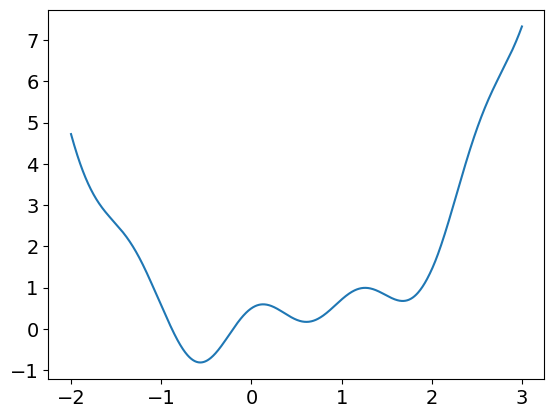

In [2]:
import matplotlib.pyplot as plt
# Increase default font sizes for all plots
plt.rcParams.update({"font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16, "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 14})
import numpy as np
x = np.linspace(-2, 3, 1000)
y = ref_potential(x)
plt.plot(x, y)
#find minima and maxima
from scipy.signal import argrelextrema
minima = argrelextrema(y, np.less)[0]
maxima = argrelextrema(y, np.greater)[0]
x[minima]
R = -0.56756757
P  = 1.677

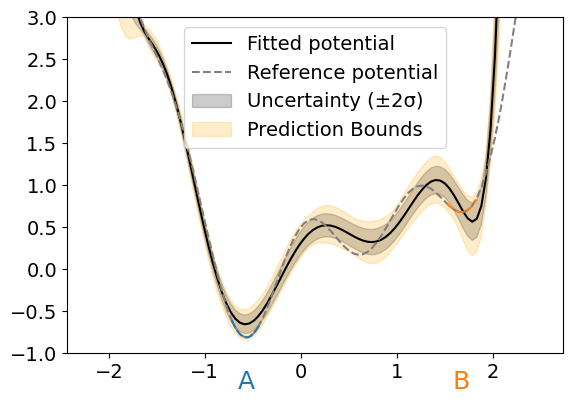

In [3]:
#fit with polynomial of degree 12, bayesian ridge
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from popsregression import POPSRegression
degree = 8
from sklearn.preprocessing import StandardScaler

# Augmenter le degré si nécessaire, mais ajouter impérativement un scaler
model = make_pipeline(
    PolynomialFeatures(degree), 
    # StandardScaler(), # Normalise les puissances de x avant le fit
    POPSRegression(leverage_percentile= 0)
)
x_min, x_max = -1.7, 2
x_train = np.linspace(x_min, x_max, 50000)
y_train = ref_potential(x_train)

model.fit(x_train[:, np.newaxis], y_train)


# Visualisation
x_dense = np.linspace(x_min-0.5, x_max+0.5, 100) # On reste dans ton intervalle de confinement
y_poly_dense, y_std, y_min, y_max = model.predict(x_dense[:, np.newaxis], return_std=True, return_bounds=   True)
plt.ylim(-1, 3) # Ajuste les limites pour mieux voir les détails
plt.plot(x_dense, y_poly_dense, label="Fitted potential", color='black')
plt.plot(x_dense, ref_potential(x_dense), label="Reference potential", linestyle='--',color = 'grey')
plt.fill_between(x_dense, y_poly_dense - 2*y_std, y_poly_dense + 2*y_std, color='black', alpha=0.2, label="Uncertainty (±2σ)")
plt.fill_between(x_dense, y_min, y_max, color='orange', alpha=0.2, label="Prediction Bounds")
plt.legend(fontsize=14)
x_r_boundary = np.linspace(R-0.15, R+0.15, 100)
y_r_boundary = ref_potential(x_r_boundary)
x_p_boundary = np.linspace(P-0.15, P+0.15, 100)
y_p_boundary = ref_potential(x_p_boundary)
plt.plot(x_r_boundary, y_r_boundary, label="Fitted near R", color='C0', linestyle='dashed')

plt.plot(x_p_boundary, y_p_boundary, label="Fitted near P", color='C1', linestyle='dashed')
# Annotate R and P below the wells with matching colors
ymin, ymax = plt.ylim()
y_text = ymin - 0.05*(ymax - ymin)
plt.text(R, y_text, 'A', color='C0', ha='center', va='top', fontsize=18)
plt.text(P, y_text, 'B', color='C1', ha='center', va='top', fontsize=18)
# Ensure tick labels are larger
plt.gca().tick_params(axis='both', labelsize=14)
# Expand bottom margin so labels are visible
plt.gcf().subplots_adjust(bottom=0.18)
# plt.show()
weights = model['popsregression'].coef_
np.save('weights.npy', weights)
plt.savefig('pops_fittedpotential.png')
posterior_samples = model['popsregression']._sample_hypercube(10000)
np.save('pops_data/posterior_samples.npy', posterior_samples[0])

In [4]:
posterior_samples

(array([[ 0.12015509, -0.01280774,  0.15064988, ...,  0.08903101,
          0.08567675, -0.01250283],
        [ 0.2766213 , -0.17839954,  0.13907958, ...,  0.01798911,
         -0.04106183,  0.00761885],
        [-0.09173824,  0.14161074, -0.62025796, ..., -0.41313871,
          0.02781278, -0.16366057],
        ...,
        [-0.01364408,  0.16910844, -0.2697249 , ..., -0.13459494,
          0.07021353, -0.11898779],
        [-0.03212237,  0.06455339, -0.03922856, ..., -0.00796571,
          0.05737939, -0.0210689 ],
        [ 0.00452433, -0.02976276,  0.03706335, ...,  0.01469536,
         -0.01353332,  0.01761526]], shape=(9, 10000)),
 array([[ 0.00479426,  0.00128166, -0.01944282, -0.00355135,  0.02118671,
          0.00260065, -0.00857891, -0.00054488,  0.00116394],
        [ 0.00128166,  0.02935704, -0.00345498, -0.0575472 ,  0.00793768,
          0.0327784 , -0.00638549, -0.00570904,  0.00145468],
        [-0.01944282, -0.00345498,  0.12036456,  0.02257193, -0.14604966,
         

In [5]:
from girsanov_uq.potentials import (
    OneDimensionalPotentialCalculator,
    Polynomial1DPotential,
    TargetFunction1DPotential,
)

potential_fit = Polynomial1DPotential(theta_vec=weights)


/tmp/ipykernel_42478/1990063258.py:8: FutureWarning: Please use atoms.calc = calc
  atoms.set_calculator(calc)


Text(0, 0.5, 'Position')

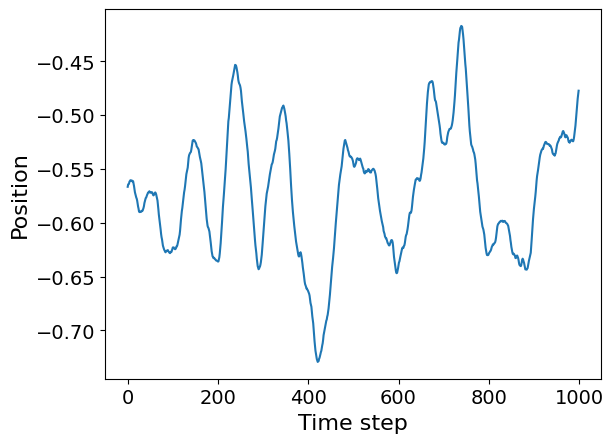

In [6]:
# compute MD with ASE
from ase import Atoms
from ase.calculators.calculator import Calculator, all_changes
from girsanov_uq.integrators.langevinOBABO import LangevinOBABO
from ase.units import fs
atoms = Atoms('H', positions=[[R, 0, 0]])
calc = OneDimensionalPotentialCalculator(potential_target)
atoms.set_calculator(calc)
dyn = LangevinOBABO(atoms, timestep=0.01, temperature_K=1000, friction=5)
#plot and run
import matplotlib.pyplot as plt
traj = []
for i in range(1000):
    dyn.run(1)
    x = atoms.get_positions()[0, 0]
    traj.append(x)
plt.plot(traj)
plt.xlabel('Time step')
plt.ylabel('Position')


In [7]:
from aseams.cvs import CollectiveVariables

def get_x(atoms):
    return float(atoms.positions[0, 0])


cv = CollectiveVariables(get_x, get_x, get_x)
cv.set_r_crit("below")
cv.set_in_r_boundary(-0.5)
cv.set_sigma_r_level(-0.48)
cv.set_out_of_r_zone(0.0)
cv.set_p_crit("above")
cv.set_in_p_boundary(P-0.1)
